# Grad-CAM Explainability for the Fine-Tuned MobileNetV2

This notebook visualizes validation examples from the final fine-tuned model: correctly classified good images, correctly classified defective images, false positives, and low-confidence or human-review cases. Grad-CAM highlights spatial regions associated with a prediction, but it does not prove a causal explanation. The reserved test split is not evaluated.

In [1]:
from __future__ import annotations
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import tensorflow as tf

SEED = 42
IMAGE_SIZE = (224, 224)
PROJECT_ROOT = Path.cwd().resolve()
MODEL_PATH = PROJECT_ROOT / 'outputs/models/milestone4/mobilenetv2_finetuned_standard_best.keras'
PREDICTIONS_PATH = PROJECT_ROOT / 'outputs/analysis/milestone5/fine_tuned_validation_predictions_and_human_review.csv'
THRESHOLD_PATH = PROJECT_ROOT / 'outputs/analysis/milestone5/fine_tuned_threshold_selection_summary.json'
FIGURE_DIR = PROJECT_ROOT / 'outputs/figures/milestone6/gradcam'
ANALYSIS_DIR = PROJECT_ROOT / 'outputs/analysis/milestone6'
FIGURE_DIR.mkdir(parents=True, exist_ok=True); ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)
tf.keras.utils.set_random_seed(SEED)
predictions = pd.read_csv(PREDICTIONS_PATH)
thresholds = json.loads(THRESHOLD_PATH.read_text(encoding='utf-8'))
binary_threshold = thresholds['selected_binary_threshold']
low_threshold = thresholds['human_review']['low_threshold']
high_threshold = thresholds['human_review']['high_threshold']
assert len(predictions) == 54
print(f'Binary threshold: {binary_threshold:.6f}')
print(f'Human-review interval: [{low_threshold:.6f}, {high_threshold:.6f})')

Binary threshold: 0.152666
Human-review interval: [0.152666, 0.439000)


## Transparent sample selection

Samples are selected deterministically. Correct good and defective cases include high-confidence examples. All false positives are retained. Low-confidence examples are the closest probabilities to the selected binary threshold, prioritizing cases assigned to human review. Categories may overlap conceptually, but duplicate images are removed from the final panel. There are no false negatives at the selected validation threshold.

In [2]:
p = predictions.copy()
p['distance_to_binary_threshold'] = (p['predicted_probability_defective'] - binary_threshold).abs()
correct_good = p[(p['binary_label']==0) & (p['error_type']=='correct')].nsmallest(2, 'predicted_probability_defective').assign(gradcam_category='Correct good')
correct_defective = p[(p['binary_label']==1) & (p['error_type']=='correct')].nlargest(2, 'predicted_probability_defective').assign(gradcam_category='Correct defective')
false_positive = p[p['error_type']=='false_positive'].sort_values('predicted_probability_defective', ascending=False).assign(gradcam_category='False positive')
review_cases = p[p['final_decision']=='Needs Human Review'].sort_values('distance_to_binary_threshold').assign(gradcam_category='Low confidence / review')
low_confidence = p.sort_values('distance_to_binary_threshold').assign(gradcam_category='Low confidence / review')
selected = pd.concat([correct_good, correct_defective, false_positive, review_cases, low_confidence], ignore_index=True)
selected = selected.drop_duplicates('relative_path', keep='first')
selected = selected.groupby('gradcam_category', group_keys=False).head(4).reset_index(drop=True)
selected['selection_order'] = np.arange(1, len(selected)+1)
display(selected[['selection_order','gradcam_category','relative_path','true_label','predicted_probability_defective','final_decision','error_type']])
print('False negatives available:', int((p['error_type']=='false_negative').sum()))

,selection_order,gradcam_category,relative_path,true_label,predicted_probability_defective,final_decision,error_type
0,1,Correct good,train/good/053.png,good,0.008345,Good,correct
1,2,Correct good,train/good/026.png,good,0.009179,Good,correct
2,3,Correct defective,test/crack/000.png,defective,0.999998,Defective,correct
3,4,Correct defective,test/crack/002.png,defective,0.999992,Defective,correct
4,5,False positive,train/good/168.png,good,0.721655,Defective,false_positive
5,6,False positive,train/good/078.png,good,0.438425,Needs Human Review,false_positive
6,7,False positive,train/good/164.png,good,0.188034,Needs Human Review,false_positive
7,8,Low confidence / review,test/gray_stroke/005.png,defective,0.152666,Needs Human Review,correct
8,9,Low confidence / review,test/gray_stroke/001.png,defective,0.373987,Needs Human Review,correct
9,10,Low confidence / review,train/good/149.png,good,0.142988,Good,correct


False negatives available: 0


In [3]:
model = tf.keras.models.load_model(MODEL_PATH, compile=False)
augmentation_layer = model.get_layer('training_augmentation')
backbone = model.get_layer('mobilenetv2_1.00_224')
pooling_layer = model.get_layer('global_average_pooling2d_1')
dropout_layer = model.get_layer('dropout_1')
classifier_layer = model.get_layer('defective_probability')
target_layer = backbone.get_layer('Conv_1')
feature_model = tf.keras.Model(backbone.input, [target_layer.output, backbone.output])

def load_rgb(path):
    image = tf.io.decode_png(tf.io.read_file(str(path)), channels=3)
    image = tf.image.resize(image, IMAGE_SIZE, antialias=True)
    return tf.cast(image, tf.float32).numpy()

def gradcam_for_defective_probability(image_array):
    batch = tf.convert_to_tensor(image_array[None, ...], dtype=tf.float32)
    augmented = augmentation_layer(batch, training=False)
    processed = tf.keras.applications.mobilenet_v2.preprocess_input(augmented)
    with tf.GradientTape() as tape:
        conv_output, backbone_output = feature_model(processed, training=False)
        tape.watch(conv_output)
        pooled = pooling_layer(backbone_output)
        dropped = dropout_layer(pooled, training=False)
        defective_probability = classifier_layer(dropped)[:, 0]
    gradients = tape.gradient(defective_probability, conv_output)
    weights = tf.reduce_mean(gradients, axis=(1,2), keepdims=True)
    heatmap = tf.reduce_sum(weights * conv_output, axis=-1)[0]
    heatmap = tf.nn.relu(heatmap)
    heatmap = heatmap / (tf.reduce_max(heatmap) + tf.keras.backend.epsilon())
    heatmap = tf.image.resize(heatmap[...,None], IMAGE_SIZE).numpy().squeeze()
    return heatmap, float(defective_probability.numpy()[0])

records = []
for _, row in selected.iterrows():
    image = load_rgb(row['source_path'])
    heatmap, reproduced_probability = gradcam_for_defective_probability(image)
    records.append({'relative_path':row['relative_path'], 'gradcam_category':row['gradcam_category'], 'stored_probability':row['predicted_probability_defective'], 'reproduced_probability':reproduced_probability, 'absolute_probability_difference':abs(reproduced_probability-row['predicted_probability_defective']), 'peak_heatmap_value':float(heatmap.max()), 'mean_heatmap_value':float(heatmap.mean())})
selected_explanations = pd.DataFrame(records)
assert selected_explanations['absolute_probability_difference'].max() < 1e-4
print('Target convolutional layer:', target_layer.name, target_layer.output.shape)
print('Maximum reproduced-probability difference:', selected_explanations['absolute_probability_difference'].max())

Target convolutional layer: Conv_1 (None, 7, 7, 1280)
Maximum reproduced-probability difference: 2.117992095929111e-06


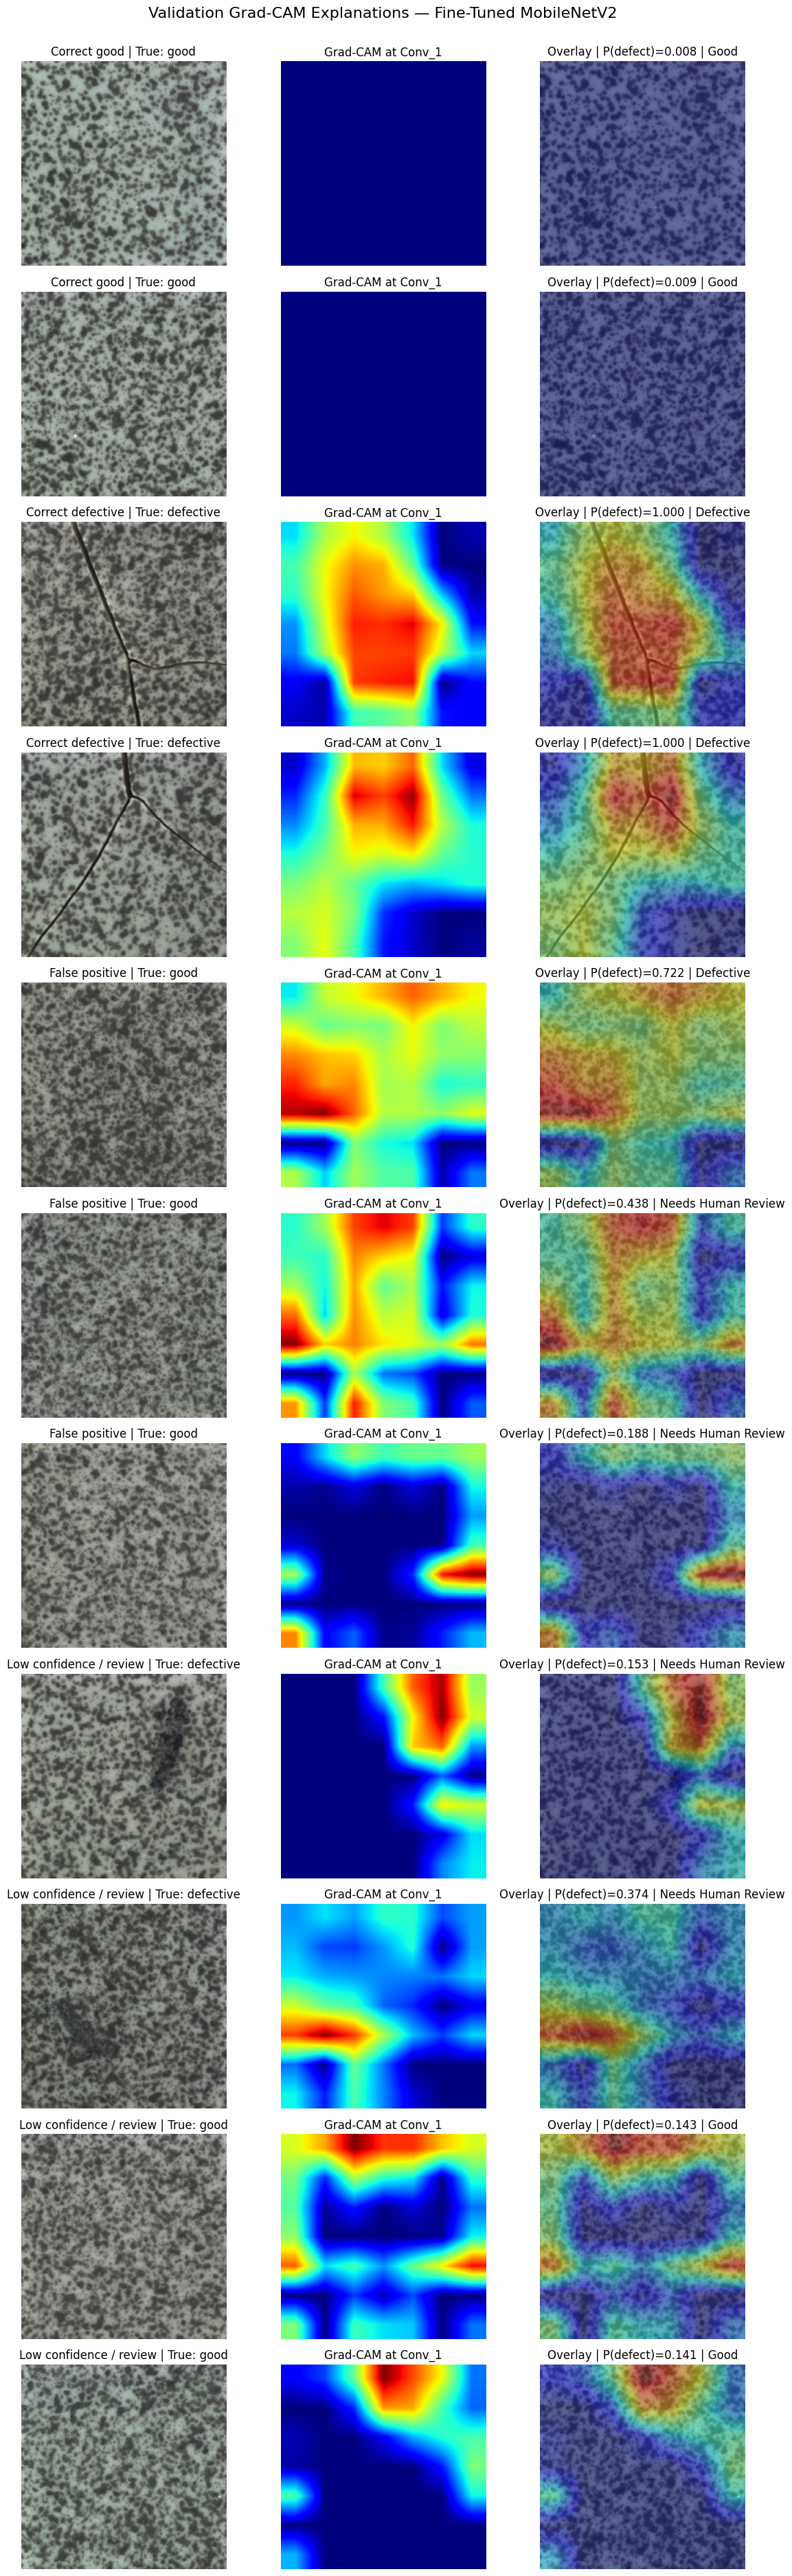

{
  "model": "mobilenetv2_finetuned_standard_best.keras",
  "target_layer": "Conv_1",
  "selected_examples": 11,
  "categories": {
    "Low confidence / review": 4,
    "False positive": 3,
    "Correct defective": 2,
    "Correct good": 2
  },
  "false_negatives_available": 0,
  "binary_threshold": 0.1526661366224289,
  "low_threshold": 0.1526661366224289,
  "high_threshold": 0.439,
  "maximum_probability_reproduction_error": 2.117992095929111e-06,
  "test_evaluated": false,
  "interpretation_warning": "Grad-CAM indicates spatial sensitivity associated with the prediction; it is not a causal explanation."
}
Saved: D:\Final Project\outputs\figures\milestone6\gradcam\fine_tuned_validation_gradcam_panel.png


In [4]:
n = len(selected)
fig, axes = plt.subplots(n, 3, figsize=(12, 3.4*n), squeeze=False)
for plot_index, (_, row) in enumerate(selected.iterrows()):
    image_float = load_rgb(row['source_path'])
    display_image = np.clip(image_float, 0, 255).astype(np.uint8)
    heatmap, reproduced_probability = gradcam_for_defective_probability(image_float)
    axes[plot_index,0].imshow(display_image); axes[plot_index,0].set_title(f"{row['gradcam_category']} | True: {row['true_label']}")
    axes[plot_index,1].imshow(heatmap, cmap='jet', vmin=0, vmax=1); axes[plot_index,1].set_title(f"Grad-CAM at {target_layer.name}")
    axes[plot_index,2].imshow(display_image); axes[plot_index,2].imshow(heatmap, cmap='jet', alpha=0.42, vmin=0, vmax=1); axes[plot_index,2].set_title(f"Overlay | P(defect)={reproduced_probability:.3f} | {row['final_decision']}")
    for ax in axes[plot_index]: ax.axis('off')
fig.suptitle('Validation Grad-CAM Explanations — Fine-Tuned MobileNetV2', fontsize=16, y=1.002)
fig.tight_layout(); panel_path = FIGURE_DIR/'fine_tuned_validation_gradcam_panel.png'; fig.savefig(panel_path,dpi=150,bbox_inches='tight'); plt.show()
selected_output = selected.merge(selected_explanations, on=['relative_path','gradcam_category'], how='left')
selected_output.to_csv(ANALYSIS_DIR/'gradcam_selected_validation_examples.csv',index=False)
summary = {'model':MODEL_PATH.name, 'target_layer':target_layer.name, 'selected_examples':len(selected), 'categories':selected['gradcam_category'].value_counts().to_dict(), 'false_negatives_available':int((p['error_type']=='false_negative').sum()), 'binary_threshold':binary_threshold, 'low_threshold':low_threshold, 'high_threshold':high_threshold, 'maximum_probability_reproduction_error':float(selected_explanations['absolute_probability_difference'].max()), 'test_evaluated':False, 'interpretation_warning':'Grad-CAM indicates spatial sensitivity associated with the prediction; it is not a causal explanation.'}
(ANALYSIS_DIR/'gradcam_summary.json').write_text(json.dumps(summary,indent=2),encoding='utf-8')
print(json.dumps(summary,indent=2)); print('Saved:', panel_path)

## Limitations

Grad-CAM is a coarse localization method derived from gradients at a late convolutional layer. A highlighted region may correlate with texture, boundaries, lighting, or background artifacts rather than the physical defect itself. Visual inspection should therefore be combined with error analysis and domain expertise.